<h1><center>Model variations - Phase transition</center></h1>
<center>This notebook purpose is to illustrate and analyze the potential phase transition of three model variations<center>

In [20]:
import numpy as np
import pandas as pd
import utils
from models import AnnLassoRegression
import tqdm

In [19]:
model_no_warmstart = AnnLassoRegression(name = "without warm start", warm_start=False)
model_warmstart_ista = AnnLassoRegression(name = "warm start, ista at each sd", warm_start=True, one_ista=False)
model_warmstart_no_ista = AnnLassoRegression(name = "warm start, ista only at end", warm_start=True, one_ista=True)

In [ ]:
pesr_history_no_warmstart = {i: [] for i in range(1, 18)}
pesr_history_warmstart_ista = {i: [] for i in range(1, 18)}
pesr_history_warmstart_no_ista = {i: [] for i in range(1, 18)}

for j in range(1, 5):
    for i in tqdm(range(1, 18), desc="Number of features progress"):
        X_train = pd.read_csv(f"dataSets{j}/s{i}/{i}-train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets{j}/s{i}/{i}-train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets{j}/s{i}/{i}-test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets{j}/s{i}/{i}-test-y.csv", header = None)

        features = pd.read_csv(f"dataSets{j}/s{i}/{i}-important_inds.csv")
        features = features.values.flatten()

        model_no_warmstart.fit(X_train, y_train, print_epochs=False, graph=False)
        pesr_history_no_warmstart[i].append(model_no_warmstart.results_analysis(X_test, y_test, features)['exact_recovery'])

        model_warmstart_ista.fit(X_train, y_train, print_epochs=False, graph=False)
        pesr_history_warmstart_ista[i].append(model_warmstart_ista.results_analysis(X_test, y_test, features)['exact_recovery'])

        model_warmstart_no_ista.fit(X_train, y_train, print_epochs=False, graph=False)
        pesr_history_warmstart_no_ista[i].append(model_warmstart_no_ista.results_analysis(X_test, y_test, features)['exact_recovery'])

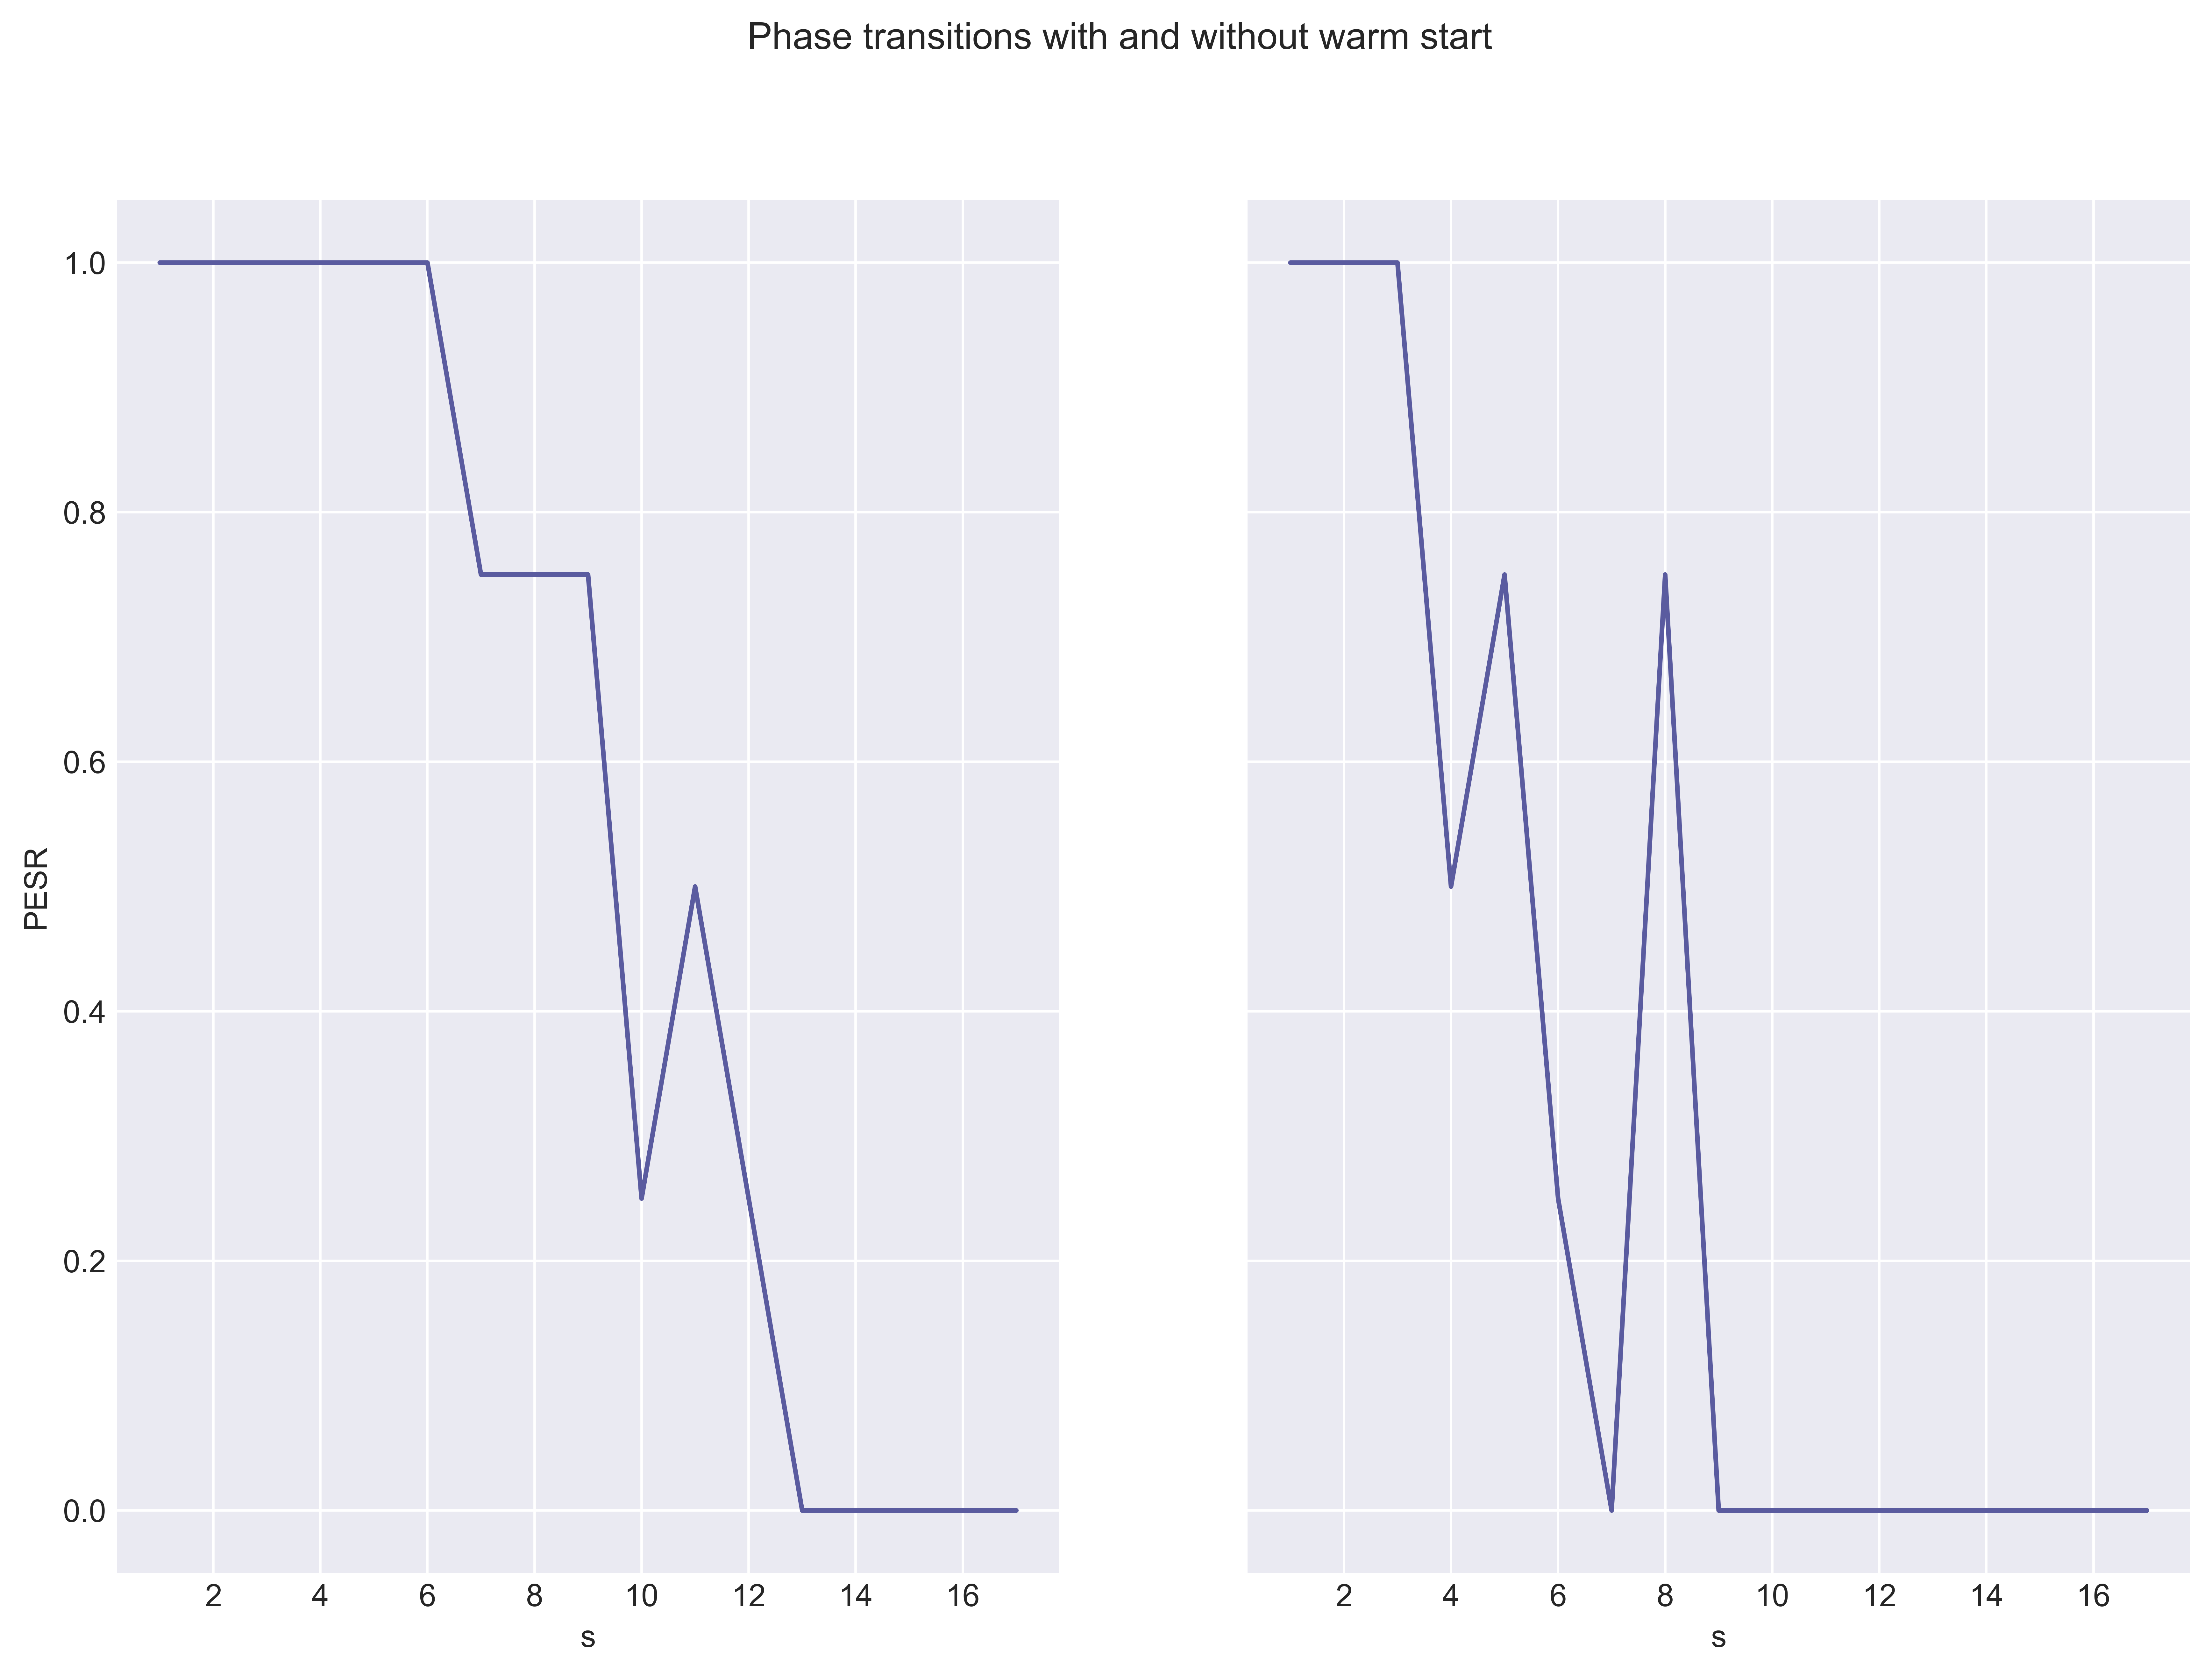

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, dpi=700, sharey=True)
fig.suptitle('Phase transitions with and without warm start')

ran = np.arange(1, 18)
mean_no_warm_start = [np.mean(pesr_history[i]) for i in ran]
mean_warm_start = [np.mean(pesr_history2[i]) for i in ran]

ax1.set_ylabel("PESR")
ax1.set_xlabel("s")
ax2.set_xlabel("s")
ax1.plot(ran, mean_warm_start)
ax2.plot(ran, mean_no_warm_start)

for ax in fig.get_axes():
    ax.label_outer()

plt.show()